# BLOCO DE MARLIM
Compara as predições dos modelos com a anotação do especialista na inline anotada de cada
patch. Fluxo: `Generator2.ipynb` → `../Dataset/dataset_marlim_opt_2/Format.ipynb` → treino
(`../Model/Analysis.ipynb`) → `Predict.ipynb` → comparação aqui.

`FaultStickExtractor` transforma o mapa de probabilidade em falhas retas; `FaultComparer`
reconstrói os volumes preditos, plota (`show`) e mede a convergência com o especialista
(`metrics`, `report`).

In [ ]:
import os, re, json, cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
from PIL import Image
from skimage.morphology import skeletonize
from tqdm import tqdm

In [2]:
BASE_PATH   = '../Model/Backup'                        # pasta dos modelos: '../Marcia' ou '../Model/Backup'
MARLIM_DIR  = '../Dataset/marlim'
PATCH_META  = 'files/patch_metadata.json'
CACHE_DIR   = 'files/cache'
FIGURES_DIR = 'files/comparisons'
INDEX_CACHE = f'{CACHE_DIR}/inline_index.json'   # patch -> fatia do slab que é a inline anotada

STICK_TOL = 0.50    # permissividade do extrator: 0 = só o traço óbvio, 1 = tudo que parecer falha
STICK_MIN = 140     # comprimento mínimo do stick, em pixels da seção
STICK_GAP = 59      # maior lacuna costurada dentro de um stick, em pixels

models = sorted(m for m in os.listdir(BASE_PATH) if os.path.isdir(f'{BASE_PATH}/{m}/marlim'))
models

['model_16', 'model_17', 'model_19', 'model_8']

In [3]:
# SUAVIZAÇÃO GAUSSIANA ISOTRÓPICA COM SIGMA EM PIXELS
def gauss(img, sigma):
    return cv2.GaussianBlur(img, (0, 0), sigmaX=sigma, sigmaY=sigma, borderType=cv2.BORDER_REFLECT)


# RESUMO DO MODELO PELO INFO.JSON, COM A JANELA DE TREINO NO RÓTULO (E O QUE SEPARA OS MODELOS NOVOS DOS ANTIGOS)
def modelSummary(name, base=None):
    path = os.path.join(base or BASE_PATH, name, 'info.json')
    info = json.load(open(path)) if os.path.exists(path) else {}

    model = info.get('model', {})
    size  = model.get('img_size')
    size  = [] if size is None else ([size] * 3 if np.isscalar(size) else list(size))

    rede   = model.get('network', '?')
    janela = '×'.join(str(int(s)) for s in size) if size else '?'
    iou    = info.get('trainer', {}).get('test_iou')

    return {
        'nome': name,
        'rede': rede,
        'janela': janela,
        'dataset': info.get('processing', {}).get('dataset', '?'),
        'iou_teste': round(float(iou), 4) if iou is not None else None,
        'rotulo': f'{name} · {rede} {janela}' + (f' (iou={iou:.3f})' if iou is not None else ''),
    }


# JANELA E SOBREPOSIÇÃO QUE O PREDICT.IPYNB REGISTROU NAQUELE PATCH
def predictSummary(patchDir):
    path = os.path.join(patchDir, 'predict.json')
    return json.load(open(path)) if os.path.exists(path) else {}


pd.DataFrame([modelSummary(m) for m in models])

,nome,rede,janela,dataset,iou_teste,rotulo
0,model_16,unet3d_v2,64×64×64,dataset_wu,0.7916,model_16 · unet3d_v2 64×64×64 (iou=0.792)
1,model_17,unet3d_v2,32×32×32,dataset_wu,0.7863,model_17 · unet3d_v2 32×32×32 (iou=0.786)
2,model_19,resaceunet_grva,128×128×128,dataset_wu,0.7791,model_19 · resaceunet_grva 128×128×128 (iou=0....
3,model_8,unet3d_v2,128×128×128,dataset_wu,0.7631,model_8 · unet3d_v2 128×128×128 (iou=0.763)


# EXTRAÇÃO DE STICKS
`FaultStickExtractor` converte um mapa de probabilidade $(z, x)$ em falhas retas, na mesma
representação em que o especialista desenha.

A predição da rede vem **pontilhada**: pedaços soltos ao longo do traço. Ligar vizinho com
vizinho fragmenta; por isso o extrator vota em **retas inteiras** — para cada orientação
plausível a seção é girada e um filtro de caixa soma a evidência numa janela reta, e os
picos viram candidatas. Cada candidata é estendida tolerando lacunas, reajustada por PCA
ponderado, e só então julgada. Os filtros usam a própria sísmica: precisa haver refletores
em volta, e a reta precisa **cortar** as camadas — falha que acompanha a estratigrafia é
artefato.

**Os quatro botões**, nesta ordem de utilidade:

| botão | o que muda | calibrado em |
|---|---|---|
| `tolerance` | quanta evidência a reta precisa reunir (0 = só o traço óbvio, 1 = tudo que parecer falha) | `STICK_TOL` |
| `minLen` | comprimento mínimo do stick, em pixels | `STICK_MIN` |
| `maxGap` | maior lacuna costurada dentro de um stick | `STICK_GAP` |
| `dipRange` | faixa de mergulho aceita, em graus | mergulho medido na anotação |

`dipRange = (43, 76)` sai da própria anotação do especialista nos quatro patches — mergulho
$p_5 = 40°$, mediana $65°$, $p_{95} = 77°$, nunca deitado e nunca vertical — e foi confirmado
por busca: os limiares de `STICK_TOL`/`STICK_MIN`/`STICK_GAP` e os 20 parâmetros internos
saíram de uma busca aleatória de 360 configurações medida em 10 pares (modelo, patch), pelo
`recall` e pela `deteccao` com o comprimento total de stick limitado a 2.5× o do especialista.

Medido nos 10 pares (modelo, patch) da calibração, contra o extrator anterior
(`recall` = fração do traço anotado coberta, `deteccao` = falhas anotadas cobertas em ≥50%,
`sticks` = quantos desenhamos para as ~33 anotadas):

| ajuste | recall | deteccao | precisao | sticks |
|---|---|---|---|---|
| extrator anterior | 0.413 | 0.362 | 0.330 | 55 |
| extrator anterior, mais permissivo | 0.517 | 0.454 | 0.260 | 98 |
| **este, `STICK_MIN = 140`** | **0.519** | **0.453** | **0.295** | **57** |
| este, `STICK_MIN = 95` | 0.540 | 0.485 | 0.262 | 77 |

Ou seja: com a mesma quantidade de traço na figura de antes, cobre 26% mais da anotação.
Baixar `STICK_MIN` para 95 rende mais 3 pontos de `deteccao` ao custo de 20 sticks a mais.

`fromRaster` faz o caminho inverso para a anotação do especialista, que assim entra na mesma
representação e pode ser comparada stick a stick.

In [4]:
class FaultStickExtractor:
    def __init__(self, tolerance=STICK_TOL, minLen=STICK_MIN, maxGap=STICK_GAP, dipRange=(43, 76), **kw):
        t = float(np.clip(tolerance, 0.0, 1.0))
        L = lambda a, b: a + (b - a) * t

        self.tolerance = t
        self.minLen    = float(minLen)
        self.maxGap    = int(maxGap)
        self.dipMin, self.dipMax = float(dipRange[0]), float(dipRange[1])

        self.evSigma  = 1.0
        self.evBudget = 0.020    # fração da seção que se espera marcada; acima disso o piso sobe
        self.evLo     = 0.20
        self.evHi     = 0.50

        self.scanMin   = 34.0    # varredura um pouco mais larga que dipRange, para o PCA ter de onde girar
        self.angleStep = 3.0
        self.seedLen   = 140
        self.seedWidth = 5
        self.seedThr   = L(0.198, 0.048)
        self.maxSeeds  = 1200
        self.nmsOffset = 9
        self.nmsAlong  = 51
        self.nmsAngle  = 9.9

        self.corrWidth    = 5
        self.supThr       = L(0.381, 0.211)
        self.traceMax     = 560
        self.stretchGap   = 86
        self.stretchFill  = 0.385
        self.stretchWidth = 8
        self.consumeWidth = 4

        self.minFill    = L(0.615, 0.415)
        self.energyMin  = 0.167
        self.energyFrac = 0.213
        self.energySigma = 25
        self.layerMin   = L(35.8, 25.8)
        self.layerSigma = 12.0

        self.mergeAngle  = 8.65
        self.mergeOffset = 6.0
        self.mergeGap    = 157.0
        self.dupCover    = 0.722
        self.dupOffset   = 17.7

        for k, v in kw.items():
            setattr(self, k, v)

        self.layer = self.coh = self.energyMap = None

    # PROBABILIDADE -> EVIDÊNCIA EM [0,1]; O PISO SOBE PELO PERCENTIL PARA PREDIÇÃO DENSA NÃO EXPLODIR O TRAÇADO
    def evidence(self, prob):
        p  = gauss(prob.astype(np.float32), self.evSigma)
        hi = max(self.evHi, float(np.percentile(p, 100 * (1 - self.evBudget))))
        lo = max(self.evLo, float(np.percentile(p, 100 * (1 - 2 * self.evBudget))))
        return np.clip((p - lo) / max(hi - lo, 1e-3), 0, 1).astype(np.float32)

    # AMPLITUDE LOCAL DA SÍSMICA: ~0 NA ÁGUA E NA ZONA MORTA, ~1 NOS REFLETORES
    def energy(self, seismic):
        sec = seismic.astype(np.float32)
        mu  = gauss(sec, self.energySigma)
        var = gauss(sec * sec, self.energySigma) - mu * mu
        E   = np.sqrt(np.clip(var, 0, None))
        return np.clip(E / (np.percentile(E, 95) + 1e-9), 0, 1).astype(np.float32)

    # TENSOR DE ESTRUTURA DA SÍSMICA -> (ÂNGULO DAS CAMADAS EM GRAUS, COERÊNCIA)
    def layering(self, seismic):
        sec = seismic.astype(np.float32)
        Ix  = cv2.Sobel(sec, cv2.CV_32F, 1, 0, ksize=3)
        Iy  = cv2.Sobel(sec, cv2.CV_32F, 0, 1, ksize=3)
        Jxx, Jyy, Jxy = gauss(Ix*Ix, self.layerSigma), gauss(Iy*Iy, self.layerSigma), gauss(Ix*Iy, self.layerSigma)

        angle = (np.degrees(0.5 * np.arctan2(2*Jxy, Jxx - Jyy)) + 90.0) % 180.0
        coh   = np.sqrt((Jxx - Jyy)**2 + 4*Jxy**2) / (Jxx + Jyy + 1e-9)
        return angle.astype(np.float32), coh.astype(np.float32)

    # ROTAÇÃO QUE DEIXA UMA RETA DE ÂNGULO phi VERTICAL NUMA TELA QUADRADA
    @staticmethod
    def rotmat(shape, angle, canvas):
        h, w = shape
        M = cv2.getRotationMatrix2D(((w - 1) / 2, (h - 1) / 2), angle, 1.0)
        M[0, 2] += (canvas - 1) / 2 - (w - 1) / 2
        M[1, 2] += (canvas - 1) / 2 - (h - 1) / 2
        return M

    # VOTAÇÃO TIPO HOUGH: EVIDÊNCIA SOMADA NUMA JANELA RETA, PARA CADA ORIENTAÇÃO PLAUSÍVEL
    def votes(self, q):
        canvas = int(np.ceil(np.hypot(*q.shape)))
        ones   = np.ones_like(q)
        ksz    = (self.seedWidth, self.seedLen)
        area   = ksz[0] * ksz[1]
        out    = []

        for phi in np.arange(self.scanMin, 180.0 - self.scanMin + 1e-6, self.angleStep):
            M = self.rotmat(q.shape, phi - 90.0, canvas)
            R = cv2.warpAffine(q,    M, (canvas, canvas), flags=cv2.INTER_LINEAR,  borderValue=0)
            V = cv2.warpAffine(ones, M, (canvas, canvas), flags=cv2.INTER_NEAREST, borderValue=0)

            num = cv2.boxFilter(R, -1, ksz, normalize=False, borderType=cv2.BORDER_CONSTANT)
            den = cv2.boxFilter(V, -1, ksz, normalize=False, borderType=cv2.BORDER_CONSTANT)
            acc = np.where(den > 0.6 * area, num / np.maximum(den, 1e-6), 0)

            peak   = acc >= cv2.dilate(acc, np.ones((self.seedLen // 2, 9), np.uint8))
            ys, xs = np.nonzero((acc >= self.seedThr) & peak)
            if not len(ys):
                continue

            inv = cv2.invertAffineTransform(M)
            pts = inv[:, :2] @ np.stack([xs, ys]).astype(np.float32) + inv[:, 2:3]
            out += [(float(s), float(x), float(y), float(phi)) for (x, y), s in zip(pts.T, acc[ys, xs])]

        out.sort(key=lambda r: -r[0])
        return out

    # DESCARTA VOTOS REDUNDANTES: A DISTÂNCIA QUE IMPORTA É A PERPENDICULAR, PORQUE A FAMÍLIA DOMINÓ É PARALELA
    def seeds(self, votes):
        cell, kept, grid = self.nmsAlong, [], {}

        for seed in votes:
            score, x, y, phi = seed
            gx, gy = int(x // cell), int(y // cell)
            near = [k for i in (gx-1, gx, gx+1) for j in (gy-1, gy, gy+1) for k in grid.get((i, j), ())]

            dup = False
            for k in near:
                _, x2, y2, phi2 = kept[k]
                da = abs(phi - phi2) % 180
                if min(da, 180 - da) > self.nmsAngle:
                    continue

                d = np.array([np.cos(np.radians(phi2)), np.sin(np.radians(phi2))])
                v = np.array([x - x2, y - y2])
                if abs(d[0]*v[1] - d[1]*v[0]) <= self.nmsOffset and abs(d @ v) <= self.nmsAlong:
                    dup = True
                    break

            if dup:
                continue

            grid.setdefault((gx, gy), []).append(len(kept))
            kept.append(seed)

            if len(kept) >= self.maxSeeds:
                break
        return kept

    # CENTRO, DIREÇÃO UNITÁRIA E COMPRIMENTO DE UM STICK
    @staticmethod
    def unit(s):
        p0, p1 = np.array(s['p0'], float), np.array(s['p1'], float)
        d  = p1 - p0
        Ln = float(np.hypot(*d)) + 1e-9
        return (p0 + p1) / 2, d / Ln, Ln

    # UM STICK: AS DUAS PONTAS, O MERGULHO ABSOLUTO, O COMPRIMENTO E O PREENCHIMENTO
    @staticmethod
    def stick(p0, p1, fill=0.0):
        d = np.asarray(p1, float) - np.asarray(p0, float)
        return dict(p0=(float(p0[0]), float(p0[1])), p1=(float(p1[0]), float(p1[1])),
                    dip=float(np.degrees(np.arctan2(abs(d[1]), abs(d[0]) + 1e-12))),
                    len=float(np.hypot(*d)), fill=round(float(fill), 3))

    # VALOR DE UM MAPA AO LONGO DA RETA: PARA CADA t, O MÁXIMO NA LARGURA DO CORREDOR
    def profile(self, m, c, d, ts, width=None):
        n    = np.array([-d[1], d[0]])
        w    = self.corrWidth if width is None else width
        offs = np.arange(-w, w + 1)
        xs   = (c[0] + ts[:, None]*d[0] + offs[None, :]*n[0]).round().astype(np.int32)
        ys   = (c[1] + ts[:, None]*d[1] + offs[None, :]*n[1]).round().astype(np.int32)
        ok   = (ys >= 0) & (ys < m.shape[0]) & (xs >= 0) & (xs < m.shape[1])

        vals = np.zeros(xs.shape, np.float32)
        vals[ok] = m[ys[ok], xs[ok]]
        return vals.max(1), ok.any(1)

    # MAIOR INTERVALO EM TORNO DE i0 CUJAS LACUNAS SEM SUPORTE CABEM EM maxGap
    @staticmethod
    def extent(sup, i0, maxGap):
        n, ends = len(sup), []

        for step in (1, -1):
            i, last, gap = i0, i0, 0
            while 0 <= i + step < n:
                i += step
                if sup[i]:
                    last, gap = i, 0
                else:
                    gap += 1
                    if gap > maxGap:
                        break
            ends.append(last)
        return ends[1], ends[0]

    # ESTENDE A SEMENTE ENQUANTO HOUVER SUPORTE, TOLERANDO LACUNAS — É ISSO QUE COSTURA OS PEDAÇOS
    def trace(self, q, x, y, phi):
        d  = np.array([np.cos(np.radians(phi)), np.sin(np.radians(phi))])
        c  = np.array([x, y], float)
        ts = np.arange(-self.traceMax, self.traceMax + 1.0)

        prof, inside = self.profile(q, c, d, ts)
        sup  = (prof >= self.supThr) & inside
        i0   = len(ts) // 2
        half = self.seedLen // 2

        if not sup[max(i0 - half, 0):i0 + half + 1].any():
            return None

        a, b = self.extent(sup, i0, self.maxGap)
        if b - a < self.minLen * 0.6:
            return None
        return self.stick(c + ts[a]*d, c + ts[b]*d, sup[a:b+1].mean())

    # PROCURA A CONTINUAÇÃO ALÉM DAS PONTAS: DEPOIS DE VALIDADA A RETA VALE ATRAVESSAR UMA LACUNA MAIOR
    def stretch(self, q, s):
        c, d, Ln = self.unit(s)
        ts = np.arange(-self.traceMax, self.traceMax + 1.0)
        prof, inside = self.profile(q, c, d, ts, self.stretchWidth)
        sup = (prof >= self.supThr) & inside

        i0 = len(ts) // 2
        a0 = max(int(i0 - Ln / 2), 0)
        b0 = min(int(i0 + Ln / 2), len(ts) - 1)
        a, b = self.extent(sup, i0, int(self.stretchGap))

        if a < a0 and sup[a:a0].mean() < self.stretchFill:
            a = a0
        if b > b0 and sup[b0:b].mean() < self.stretchFill:
            b = b0
        return self.stick(c + ts[a]*d, c + ts[b]*d, sup[a:b+1].mean())

    # REAJUSTA A RETA AO CENTRO DE MASSA DA EVIDÊNCIA DENTRO DO CORREDOR
    def refine(self, q, s, iters=2):
        for _ in range(iters):
            c, d, Ln = self.unit(s)
            if Ln < 4:
                return s

            n    = np.array([-d[1], d[0]])
            ts   = np.arange(-Ln / 2, Ln / 2 + 1.0)
            offs = np.arange(-self.corrWidth, self.corrWidth + 1)
            X = c[0] + ts[:, None]*d[0] + offs[None, :]*n[0]
            Y = c[1] + ts[:, None]*d[1] + offs[None, :]*n[1]

            xi, yi = X.round().astype(np.int32), Y.round().astype(np.int32)
            ok = (yi >= 0) & (yi < q.shape[0]) & (xi >= 0) & (xi < q.shape[1])
            w  = np.zeros(X.shape, np.float32)
            w[ok] = q[yi[ok], xi[ok]]
            if w.sum() < 1e-3:
                return s

            wf = w.ravel()
            P  = np.stack([X.ravel(), Y.ravel()])
            cm = (P * wf).sum(1) / wf.sum()
            P0 = P - cm[:, None]
            ev, V = np.linalg.eigh((P0 * wf) @ P0.T / wf.sum())

            dn = V[:, -1] * (1 if V[1, -1] >= 0 else -1)
            if abs(float(dn @ d)) < 0.985:          # rejeita giros bruscos
                return s

            t = dn @ P0
            s = self.stick(cm + dn*t.min(), cm + dn*t.max(), s['fill'])
        return s

    # FRAÇÃO DO COMPRIMENTO DA RETA EM QUE O MAPA PASSA DO LIMIAR
    def fracAbove(self, m, s, thr):
        c, d, Ln = self.unit(s)
        prof, _ = self.profile(m, c, d, np.arange(-Ln / 2, Ln / 2 + 1.0))
        return float((prof >= thr).mean())

    # ÂNGULO ENTRE A RETA E AS CAMADAS (MEDIANA PONDERADA PELA COERÊNCIA)
    def cutAngle(self, s):
        c, d, Ln = self.unit(s)
        ts = np.arange(-Ln / 2, Ln / 2 + 1.0)
        xi = np.clip((c[0] + ts*d[0]).round().astype(int), 0, self.layer.shape[1] - 1)
        yi = np.clip((c[1] + ts*d[1]).round().astype(int), 0, self.layer.shape[0] - 1)

        diff = np.abs(self.layer[yi, xi] - np.degrees(np.arctan2(d[1], d[0])) % 180) % 180
        diff = np.minimum(diff, 180 - diff)

        w = self.coh[yi, xi]
        if w.sum() < 1e-6:
            return 90.0

        o = np.argsort(diff)
        return float(diff[o][np.searchsorted(np.cumsum(w[o]) / w.sum(), 0.5)])

    # DESCARTA O QUE NÃO PARECE FALHA: FORA DA FAIXA DE MERGULHO, CURTA, MAL PREENCHIDA, SEM REFLETORES OU PARALELA ÀS CAMADAS
    def accept(self, s):
        if not (self.dipMin <= s['dip'] <= self.dipMax) or s['len'] < self.minLen or s['fill'] < self.minFill:
            return False

        if self.energyMap is not None:
            s['energy'] = round(self.fracAbove(self.energyMap, s, self.energyMin), 3)
            if s['energy'] < self.energyFrac:
                return False

        if self.layer is not None:
            s['cut'] = round(self.cutAngle(s), 1)
            if s['cut'] < self.layerMin:
                return False
        return True

    # ZERA O CORREDOR DA RETA ACEITA, PARA A PRÓXIMA SEMENTE NÃO REDESENHAR A MESMA FALHA
    def consume(self, res, s):
        c, d, Ln = self.unit(s)
        n    = np.array([-d[1], d[0]])
        ts   = np.arange(-Ln / 2, Ln / 2 + 1.0)
        offs = np.arange(-self.consumeWidth, self.consumeWidth + 1)
        xs = (c[0] + ts[:, None]*d[0] + offs[None, :]*n[0]).round().astype(np.int32)
        ys = (c[1] + ts[:, None]*d[1] + offs[None, :]*n[1]).round().astype(np.int32)
        ok = (ys >= 0) & (ys < res.shape[0]) & (xs >= 0) & (xs < res.shape[1])
        res[ys[ok], xs[ok]] = 0.0

    # DUAS RETAS SÃO O MESMO TRAÇO: MESMA DIREÇÃO, PONTAS PRÓXIMAS E SEM DEGRAU LATERAL
    def near(self, a, b):
        (ca, da, La), (cb, db, Lb) = self.unit(a), self.unit(b)
        if np.degrees(np.arccos(np.clip(abs(float(da @ db)), 0, 1))) > self.mergeAngle:
            return False

        ea = [np.array(a['p0']), np.array(a['p1'])]
        eb = [np.array(b['p0']), np.array(b['p1'])]
        if min(np.linalg.norm(x - y) for x in ea for y in eb) > self.mergeGap:
            return False
        return max(abs(da[0]*(p - ea[0])[1] - da[1]*(p - ea[0])[0]) for p in eb) <= self.mergeOffset

    # FUNDE OS GRUPOS DE RETAS COLINEARES NUMA SÓ, PELO PCA DAS PONTAS
    def merge(self, sticks):
        parent = list(range(len(sticks)))

        def find(i):
            while parent[i] != i:
                parent[i] = parent[parent[i]]
                i = parent[i]
            return i

        for i in range(len(sticks)):
            for j in range(i + 1, len(sticks)):
                if self.near(sticks[i], sticks[j]):
                    parent[find(i)] = find(j)

        groups = {}
        for i in range(len(sticks)):
            groups.setdefault(find(i), []).append(i)

        out = []
        for idx in groups.values():
            if len(idx) == 1:
                out.append(sticks[idx[0]])
                continue

            pts = np.array([sticks[i]['p0'] for i in idx] + [sticks[i]['p1'] for i in idx], float)
            c   = pts.mean(0)
            P0  = (pts - c).T
            ev, V = np.linalg.eigh(P0 @ P0.T / len(pts))
            d = V[:, -1] * (1 if V[1, -1] >= 0 else -1)
            t = d @ P0
            out.append(self.stick(c + d*t.min(), c + d*t.max(), np.mean([sticks[i]['fill'] for i in idx])))
        return out

    # FRAÇÃO DE `a` QUE CORRE COLADA EM `b`
    def overlap(self, a, b):
        p0, p1 = np.array(a['p0'], float), np.array(a['p1'], float)
        P = p0 + (p1 - p0) * np.linspace(0, 1, max(int(a['len'] / 4) + 1, 2))[:, None]
        q0, q1 = np.array(b['p0'], float), np.array(b['p1'], float)
        v = q1 - q0
        u = np.clip(((P - q0) @ v) / (v @ v + 1e-9), 0, 1)
        return float((np.linalg.norm(P - (q0 + u[:, None]*v), axis=1) <= self.dupOffset).mean())

    # TIRA A RETA QUE JÁ CORRE POR CIMA DE OUTRA MAIOR — É O QUE POLUI A FIGURA
    def dedup(self, sticks):
        out = []
        for s in sorted(sticks, key=lambda s: -s['len']):
            if not any(self.overlap(s, o) >= self.dupCover for o in out):
                out.append(s)
        return out

    # MATCHING PURSUIT: ACEITA A MELHOR RETA, CONSOME O CORREDOR DELA, SEGUE PARA A PRÓXIMA
    def pursue(self, q, res, seeds):
        sticks = []

        for score, x, y, phi in seeds:
            s = self.trace(res, x, y, phi)
            if s is None:
                continue

            s = self.refine(q, s)
            s['fill'] = self.fracAbove(res, s, self.supThr)
            if not self.accept(s):
                continue

            s = self.refine(q, self.stretch(res, s))
            self.consume(res, s)
            sticks.append(s)
        return sticks

    # DA EVIDÊNCIA AOS STICKS FINAIS: PERSEGUIR, FUNDIR, REMEDIR O PREENCHIMENTO E TIRAR AS REPETIDAS
    def build(self, q, votes):
        res    = q.copy()
        sticks = self.merge(self.pursue(q, res, self.seeds(votes)))

        for s in sticks:
            s['fill'] = self.fracAbove(q, s, self.supThr)

        sticks = [s for s in sticks if s['len'] >= self.minLen and s['fill'] >= self.minFill * 0.9]
        return sorted(self.dedup(sticks), key=lambda s: -s['len'])

    # STICKS DE UM MAPA DE PROBABILIDADE; A SÍSMICA LIGA OS FILTROS DE ENERGIA E DE CORTE DAS CAMADAS
    def extract(self, prob, seismic=None):
        if seismic is not None:
            self.energyMap = self.energy(seismic)
            self.layer, self.coh = self.layering(seismic)
        else:
            self.energyMap = self.layer = self.coh = None

        q = self.evidence(prob)
        return self.build(q, self.votes(q))

    # ANOTAÇÃO DO ESPECIALISTA -> STICKS: ESQUELETIZA, CORTA NAS JUNÇÕES E ENDIREITA OS PEDAÇOS
    @classmethod
    def fromRaster(cls, mask, maxdev=7.0, minlen=30, mergeGap=70.0):
        sk = skeletonize(np.asarray(mask) > 0.5)
        nb = ndi.convolve(sk.astype(np.uint8), np.ones((3, 3), np.uint8), mode='constant') - sk
        lbl, n = ndi.label(sk & (nb <= 2), structure=np.ones((3, 3)))

        out = []
        for i, sl in enumerate(ndi.find_objects(lbl), 1):
            ys, xs = np.nonzero(lbl[sl] == i)
            if len(ys) < minlen:
                continue
            out += cls.splitCurve(ys + sl[0].start, xs + sl[1].start, maxdev, minlen)

        return cls(mergeGap=mergeGap, mergeAngle=10.0, mergeOffset=10.0).merge(out)

    # QUEBRA UM TRAÇO TORTO NO PONTO DE MAIOR DESVIO ATÉ CADA PEDAÇO CABER EM maxdev
    @classmethod
    def splitCurve(cls, ys, xs, maxdev, minlen, depth=0):
        P = np.stack([xs, ys]).astype(float)
        c = P.mean(1)
        P0 = P - c[:, None]
        ev, V = np.linalg.eigh(P0 @ P0.T / P.shape[1])

        d = V[:, -1] * (1 if V[1, -1] >= 0 else -1)
        t = d @ P0
        dev = np.abs(-d[1]*P0[0] + d[0]*P0[1])

        if dev.max() > maxdev and depth < 6 and len(ys) >= 2 * minlen:
            m = t <= t[int(np.argmax(dev))]
            if m.sum() >= minlen and (~m).sum() >= minlen:
                return (cls.splitCurve(ys[m], xs[m], maxdev, minlen, depth + 1) +
                        cls.splitCurve(ys[~m], xs[~m], maxdev, minlen, depth + 1))

        if t.max() - t.min() < minlen:
            return []
        return [cls.stick(c + d*t.min(), c + d*t.max(), 1.0)]


anotado = FaultStickExtractor.fromRaster(np.array(Image.open('files/patches/1200/1200_interpretado.png').convert('L')) > 128)
pd.DataFrame([{
    'sticks': len(anotado), 'comprimento p10/p50/p90': np.round(np.percentile([s['len'] for s in anotado], [10, 50, 90])).tolist(),
    'mergulho p5/p50/p95': np.round(np.percentile([s['dip'] for s in anotado], [5, 50, 95])).tolist()
}])

,sticks,comprimento p10/p50/p90,mergulho p5/p50/p95
0,33,"[57.0, 220.0, 433.0]","[40.0, 62.0, 75.0]"


# COMPARAÇÃO DE FALHAS
`FaultComparer` monta os volumes a partir dos tiles `.dat`, localiza a inline anotada e
compara ali. `show(mode=...)` desenha a predição sobre a sísmica (`'seismic'`), a máscara em
fundo preto (`'mask'`), a sísmica limpa ao lado da máscara (`'both'`) e as falhas retas
nossas e do especialista (`'sticks'`).

**Como ler as métricas.** O especialista anotou só as falhas principais, não todas. Logo
`precisao` é um *limite inferior* — um stick nosso fora da anotação pode estar certo — e o
que mede convergência é `recall` (fração do traço anotado que cobrimos) e `deteccao` (fração
das falhas anotadas cobertas em ≥50%).

In [ ]:
class FaultComparer:
    # painel -> (rótulo, fundo preto, desenhar como sticks, desenhar as predições)
    PANELS = {
        'seismic': [('sísmica', False, False, True)],
        'mask':    [('máscara', True,  False, True)],
        'sticks':  [('sticks',  False, True,  True)],
        'both':    [('sísmica', False, False, False), ('máscara', True, False, True)],
    }

    def __init__(self, img=None, preds=None, metadata=PATCH_META, tolerance=STICK_TOL, matchTol=12.0, matchAngle=20.0, **options):
        meta = json.load(open(metadata))
        self.ps    = self.triple(meta['patch_size'])      # tile do Marlim (128³), não a janela do modelo
        self.ov    = self.triple(meta['overlap_voxels'])
        self.shape = tuple(meta['original_shape'])

        self.img        = img
        self.preds      = [dict(p) for p in (preds or [])]
        self.tolerance  = tolerance
        self.matchTol   = matchTol
        self.matchAngle = matchAngle
        self.options    = options

        self.maps, self.lines, self.tools = {}, {}, {}
        self.bg, self.idx = None, None

    # ESCALAR OU LISTA DO PATCH_METADATA VIRA TUPLA DE 3 EIXOS
    @staticmethod
    def triple(value):
        return tuple(int(v) for v in (value if isinstance(value, (list, tuple)) else [value] * 3))

    @property
    def pid(self):
        return str(self.img).rstrip('/').split('_')[-1] if self.img else None

    # SUBPASTA COM OS TILES .DAT — O PREDICT GRAVA EM masks/, O DATASET DEIXA NA RAIZ
    def tiles(self, path):
        for sub in ('', 'masks', 'images', 'predictions'):
            d = os.path.join(path, sub)
            if os.path.isdir(d) and any(f.startswith('patch_d') and f.endswith('.dat') for f in os.listdir(d)):
                return d
        raise FileNotFoundError(f'nenhum patch_*.dat em {path}')

    # MONTA O SLAB A PARTIR DOS TILES; O SHAPE VEM DO PATCH_METADATA, NUNCA DA JANELA DO MODELO
    def reconstruct(self, path, desc='montando'):
        ps, ov  = self.ps, self.ov
        stride  = tuple(p - 2 * o for p, o in zip(ps, ov))
        lastIdx = [n // s for n, s in zip(self.shape, stride)]
        vol     = np.zeros(self.shape, np.float32)

        for fname in tqdm(sorted(os.listdir(path)), desc=desc):
            m = re.match(r'patch_d(\d+)_h(\d+)_w(\d+)\.dat', fname)
            if not m:
                continue

            origin = [max(0, size - st) if idx == last else idx * st
                      for idx, last, size, st in zip(map(int, m.groups()), lastIdx, self.shape, stride)]
            data = np.fromfile(os.path.join(path, fname), np.float32)

            if data.size != int(np.prod(ps)):
                raise ValueError(f'{fname}: {data.size} valores, esperado {ps} — patch_metadata.json de outro patch?')

            core = data.reshape(ps)[ov[0]:ps[0]-ov[0], ov[1]:ps[1]-ov[1], ov[2]:ps[2]-ov[2]]
            d, h, w    = origin
            cd, ch, cw = [min(c, s - o) for c, s, o in zip(core.shape, self.shape, origin)]
            vol[d:d+cd, h:h+ch, w:w+cw] = core[:cd, :ch, :cw]

        return vol

    # TABELA patch -> FATIA, GRAVADA PARA NÃO REFAZER A CORRELAÇÃO A CADA EXECUÇÃO
    @staticmethod
    def indexTable():
        return json.load(open(INDEX_CACHE)) if os.path.exists(INDEX_CACHE) else {}

    # FATIA DO SLAB QUE CORRESPONDE À INLINE ANOTADA — NÃO É shape[0] // 2
    @property
    def inline(self):
        if self.idx is None:
            table = self.indexTable()
            self.idx = table[self.pid] if self.pid in table else self.locate()
        return self.idx

    # LOCALIZA A INLINE ANOTADA CORRELACIONANDO O SLAB COM A PNG DE REFERÊNCIA
    def locate(self):
        pid  = self.pid
        ref  = f'files/patches/{pid}/{pid}.png'
        vol  = self.reconstruct(self.tiles(self.img), f'localizando inline {pid}')
        norm = lambda a: (a - a.mean()) / (a.std() + 1e-9)

        if os.path.exists(ref):
            target = norm(np.asarray(Image.open(ref).convert('L'), np.float32))
            corr   = [float((norm(vol[k].astype(np.float32)) * target).mean()) for k in range(vol.shape[0])]
            idx    = int(np.argmax(corr))
            print(f'[{pid}] inline anotada na fatia {idx}/{vol.shape[0]} (r={max(corr):.3f})')
        else:
            idx = vol.shape[0] // 2
            print(f'[{pid}] sem {ref} — usando o meio do slab ({idx}), seção pode não ser a anotada')

        os.makedirs(CACHE_DIR, exist_ok=True)
        self.bg = vol[idx].copy()
        np.save(f'{CACHE_DIR}/real_center_{pid}.npy', self.bg)
        json.dump({**self.indexTable(), pid: idx}, open(INDEX_CACHE, 'w'), indent=2)
        return idx

    # SÍSMICA DA INLINE ANOTADA, DO CACHE QUANDO ELE JÁ EXISTE
    @property
    def background(self):
        if self.bg is None and self.img:
            cache = f'{CACHE_DIR}/real_center_{self.pid}.npy'
            table = self.indexTable()

            if self.pid in table and os.path.exists(cache):
                self.idx, self.bg = table[self.pid], np.load(cache)
            else:
                self.inline           # resolve o índice e popula bg / cache
        return self.bg

    # SEÇÃO 2D DE UMA PREDIÇÃO: PNG DA ANOTAÇÃO, .NPY JÁ MONTADO OU OS TILES DO PATCH
    def section(self, label):
        if label not in self.maps:
            path = str(next(p for p in self.preds if p['label'] == label)['path'])

            if path.endswith('.png'):
                sec = (np.array(Image.open(path).convert('L')) > 128).astype(np.float32)
            elif path.endswith('.npy'):
                vol = np.load(path, mmap_mode='r')
                sec = np.asarray(vol[self.inline] if vol.ndim == 3 else vol, np.float32)
            else:
                sec = np.asarray(self.reconstruct(self.tiles(path), label)[self.inline], np.float32)

            self.maps[label] = sec
        return self.maps[label]

    # INJETA UMA SEÇÃO JÁ CALCULADA, PARA NÃO REMONTAR O MESMO VOLUME DUAS VEZES
    def setSection(self, label, section):
        self.maps[label] = np.asarray(section, np.float32)

    @staticmethod
    def isAnnotation(p):
        return str(p['path']).lower().endswith('.png')

    # RÓTULO DA ANOTAÇÃO DO ESPECIALISTA, SE ELA ESTIVER ENTRE AS PREDIÇÕES
    def reference(self):
        return next((p['label'] for p in self.preds if self.isAnnotation(p)), None)

    # UM EXTRATOR POR TOLERÂNCIA, REAPROVEITADO ENTRE AS PREDIÇÕES
    def extractor(self, tolerance=None):
        t = float(self.tolerance if tolerance is None else tolerance)
        if t not in self.tools:
            self.tools[t] = FaultStickExtractor(tolerance=t, **self.options)
        return self.tools[t]

    # STICKS DE UMA PREDIÇÃO — A ANOTAÇÃO ENTRA PELO fromRaster, NA MESMA REPRESENTAÇÃO
    def sticks(self, label, tolerance=None):
        t   = float(self.tolerance if tolerance is None else tolerance)
        key = (label, t)

        if key not in self.lines:
            p = next(q for q in self.preds if q['label'] == label)
            self.lines[key] = (FaultStickExtractor.fromRaster(self.section(label))
                               if self.isAnnotation(p)
                               else self.extractor(t).extract(self.section(label), seismic=self.background))
        return self.lines[key]

    @staticmethod
    def sample(s, step=1.0):
        p0, p1 = np.array(s['p0'], float), np.array(s['p1'], float)
        n = max(int(np.linalg.norm(p1 - p0) / step) + 1, 2)
        return p0 + (p1 - p0) * np.linspace(0, 1, n)[:, None]

    @staticmethod
    def angle(s):
        d = np.array(s['p1'], float) - np.array(s['p0'], float)
        return float(np.degrees(np.arctan2(d[1], d[0])) % 180)

    # FRAÇÃO DO COMPRIMENTO DE `a` QUE PASSA A MENOS DE `tol` DE ALGUM `others`
    @classmethod
    def covered(cls, a, others, tol, angTol):
        P   = cls.sample(a)
        hit = np.zeros(len(P), bool)

        for o in others:
            da = abs(cls.angle(a) - cls.angle(o)) % 180
            if min(da, 180 - da) > angTol:
                continue

            p0, p1 = np.array(o['p0'], float), np.array(o['p1'], float)
            v = p1 - p0
            t = np.clip(((P - p0) @ v) / (v @ v + 1e-9), 0, 1)
            hit |= np.linalg.norm(P - (p0 + t[:, None] * v), axis=1) <= tol

        return float(hit.mean())

    # CONVERGÊNCIA DOS STICKS DE `label` COM OS DO ESPECIALISTA: recall, deteccao E precisao (LIMITE INFERIOR)
    def metrics(self, label, ref=None, tolerance=None, hit=0.5):
        ref = ref or self.reference()
        if ref is None:
            raise ValueError('nenhuma anotação do especialista entre as predições')

        mine, gt = self.sticks(label, tolerance), self.sticks(ref)
        gtCov = np.array([self.covered(g, mine, self.matchTol, self.matchAngle) for g in gt]) if gt else np.zeros(0)
        myCov = np.array([self.covered(m, gt, self.matchTol, self.matchAngle) for m in mine]) if mine else np.zeros(0)
        gtLen = np.array([g['len'] for g in gt]) if gt else np.zeros(0)
        myLen = np.array([m['len'] for m in mine]) if mine else np.zeros(0)

        R = float((gtCov * gtLen).sum() / (gtLen.sum() + 1e-9))
        P = float((myCov * myLen).sum() / (myLen.sum() + 1e-9))
        return dict(modelo=label,
                    recall=round(R, 3),
                    deteccao=round(float((gtCov >= hit).mean()) if len(gtCov) else 0.0, 3),
                    precisao=round(P, 3),
                    f1=round(2 * R * P / (R + P + 1e-9), 3),
                    sticks=len(mine),
                    falhas_gt=len(gt),
                    len_p50=round(float(np.median(myLen)), 1) if len(myLen) else 0.0,
                    len_total=int(myLen.sum()),
                    len_total_gt=int(gtLen.sum()))

    # TABELA DE CONVERGÊNCIA PARA TODAS AS PREDIÇÕES, MENOS A ANOTAÇÃO
    def report(self, tolerance=None):
        ref  = self.reference()
        rows = [self.metrics(p['label'], ref, tolerance) for p in self.preds if p['label'] != ref]
        return pd.DataFrame(rows).sort_values('recall', ascending=False).reset_index(drop=True)

    # DESENHA AS PREDIÇÕES: PONTOS PARA A ANOTAÇÃO, MÁSCARA OU STICKS PARA AS REDES
    def plotPreds(self, ax, dark, asSticks, tolerance, threshold, alpha):
        for i, p in enumerate(self.preds):
            color, z = to_rgb(p['color']), 2 + i

            if self.isAnnotation(p) and not asSticks:
                gy, gx = np.where(self.section(p['label']) > 0.5)
                ax.scatter(gx, gy, s=0.05, c=[color], alpha=0.8, zorder=z)
            elif asSticks:
                lw = 2.2 if self.isAnnotation(p) else 1.6
                for s in self.sticks(p['label'], tolerance):
                    ax.plot([s['p0'][0], s['p1'][0]], [s['p0'][1], s['p1'][1]], color=color, lw=lw, zorder=z)
            else:
                m    = self.section(p['label']) >= threshold
                rgba = np.zeros((*m.shape, 4), np.float32)
                rgba[..., :3] = color
                rgba[..., 3]  = m * (1.0 if dark else alpha)
                ax.imshow(rgba, aspect='auto', zorder=z)

    # UMA FIGURA DO PAINEL PEDIDO; save GRAVA EM DISCO EM VEZ DE MOSTRAR
    def show(self, mode='seismic', tolerance=None, threshold=0.5, alpha=1.0,
             figsize=(15, 9), save=None, title=None):
        panels  = self.PANELS[mode]
        empty   = np.zeros(self.shape[1:])
        seismic = self.background if self.background is not None else empty
        fig, axes = plt.subplots(1, len(panels), figsize=(figsize[0] * len(panels), figsize[1]), squeeze=False)

        for ax, (name, dark, asSticks, draw) in zip(axes[0], panels):
            ax.imshow(empty if dark else seismic, cmap='gray', aspect='auto', zorder=0)

            if not draw:
                ax.set_title(f'{title} — {name}' if title else name)
                continue

            detail = f'tolerance {self.extractor(tolerance).tolerance}' if asSticks else f'threshold {threshold}'
            ax.set_title(f'{title} — {name} ({detail})' if title else f'{name} ({detail})')
            self.plotPreds(ax, dark, asSticks, tolerance, threshold, alpha)
            ax.legend(handles=[Patch(facecolor=to_rgb(p['color']), label=p['label']) for p in self.preds], loc='upper right', framealpha=0.9)

        plt.tight_layout()

        if save:
            os.makedirs(os.path.dirname(save) or '.', exist_ok=True)
            plt.savefig(save, dpi=200, bbox_inches='tight')
            plt.close(fig)
            return print(f'figura salva em {save}')

        plt.show()


comparer = FaultComparer(img=f'{MARLIM_DIR}/patch_1200', preds=[{'label': 'interpretado', 'path': 'files/patches/1200/1200_interpretado.png', 'color': 'blue'}])
print(f'patch 1200 — inline anotada: fatia {comparer.inline} de {comparer.shape[0]}, seção {comparer.background.shape}')

patch 1200 — inline anotada: fatia 16 de 64, seção (1601, 2240)


# TESTES NO BLOCO DE MARLIM

model_16 · unet3d_v2 64×64×64 (iou=0.792): 100%|██████████| 910/910 [00:06<00:00, 131.37it/s]


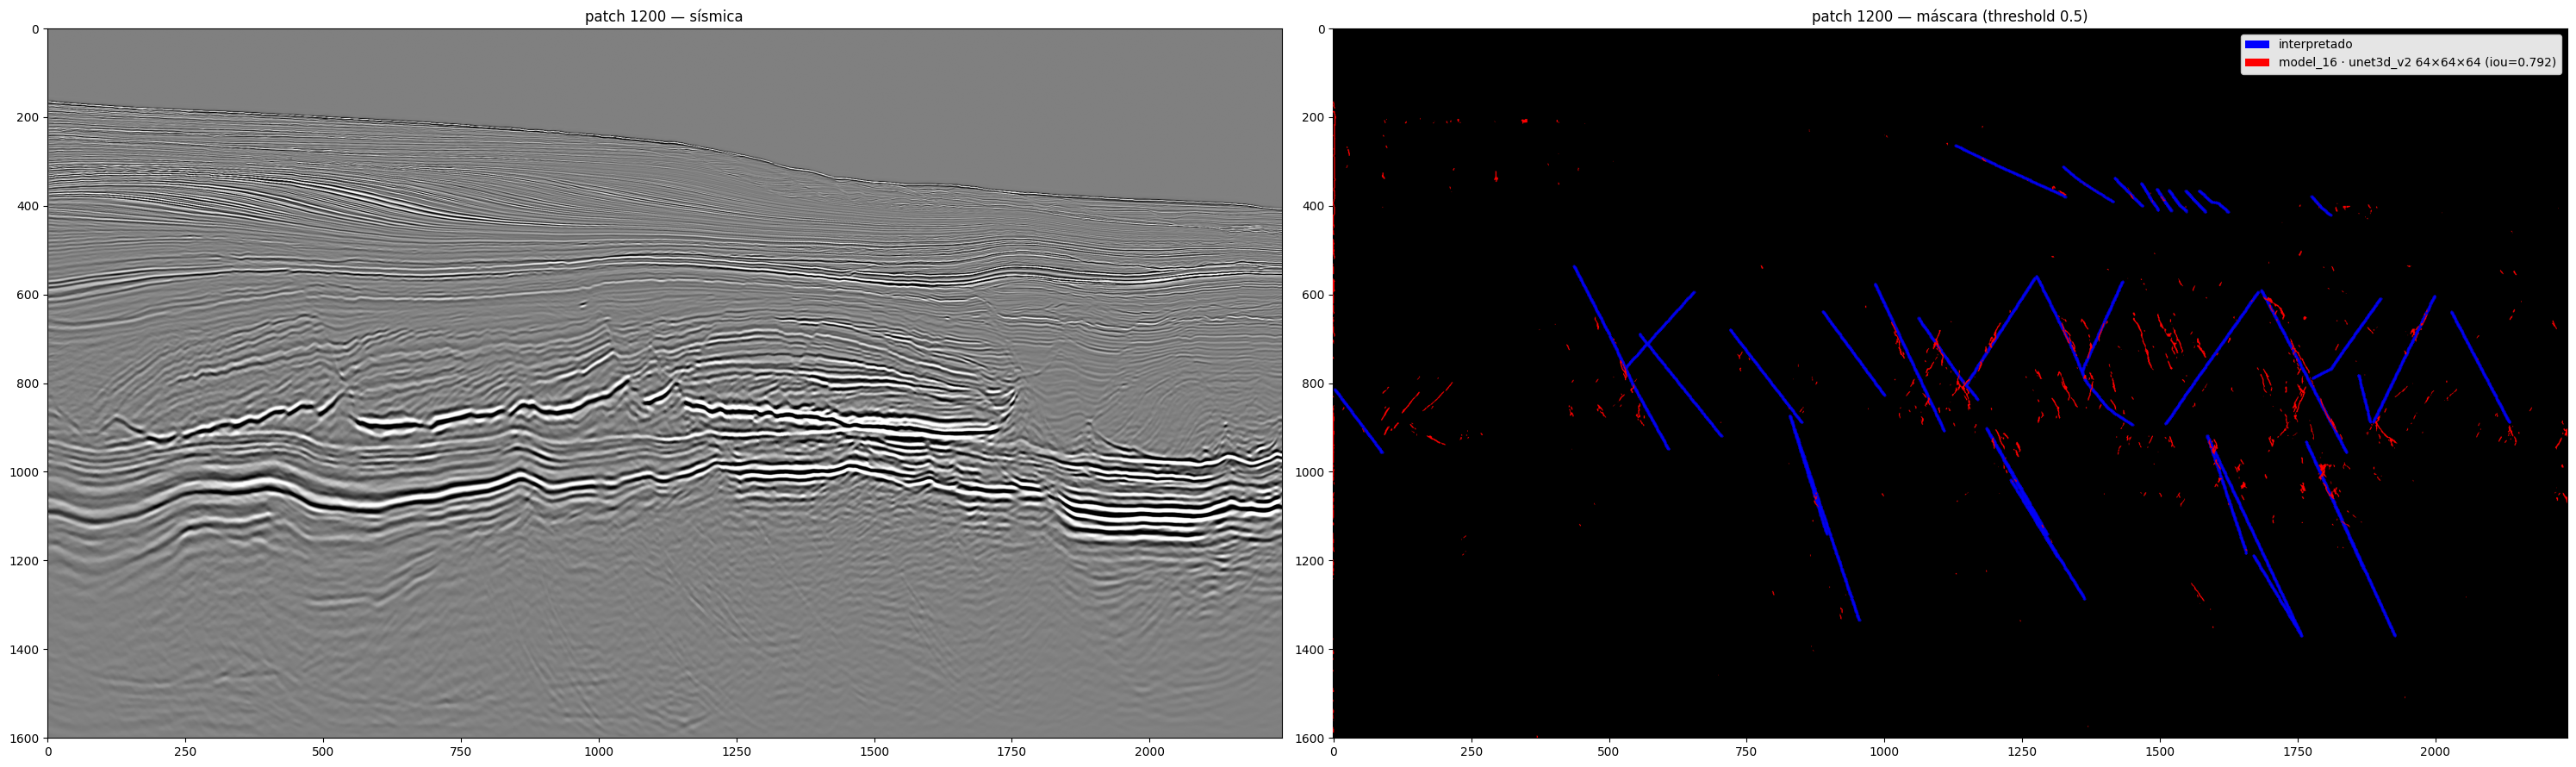

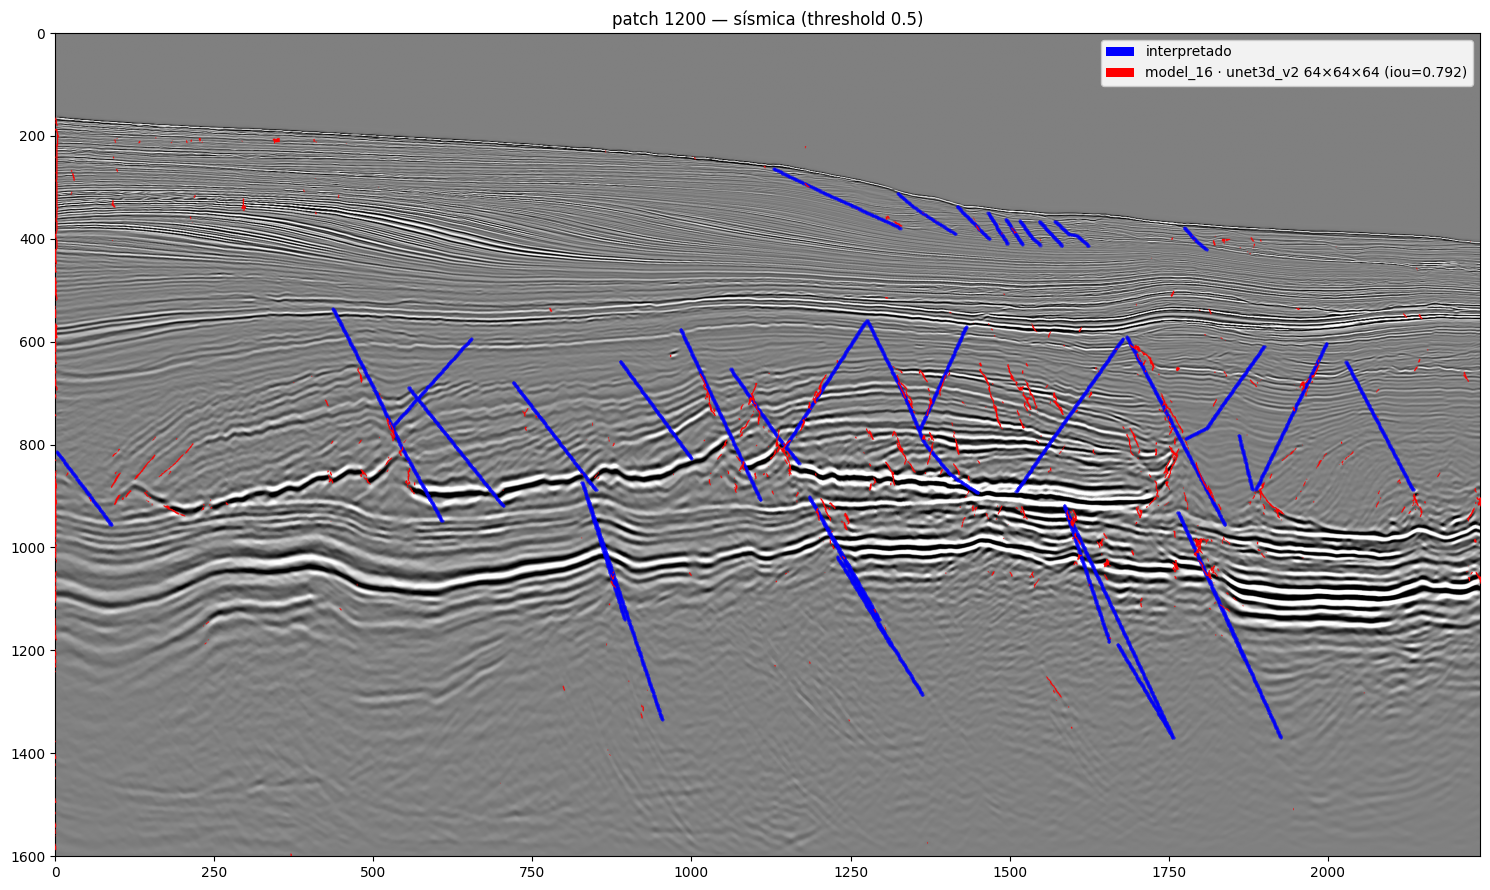

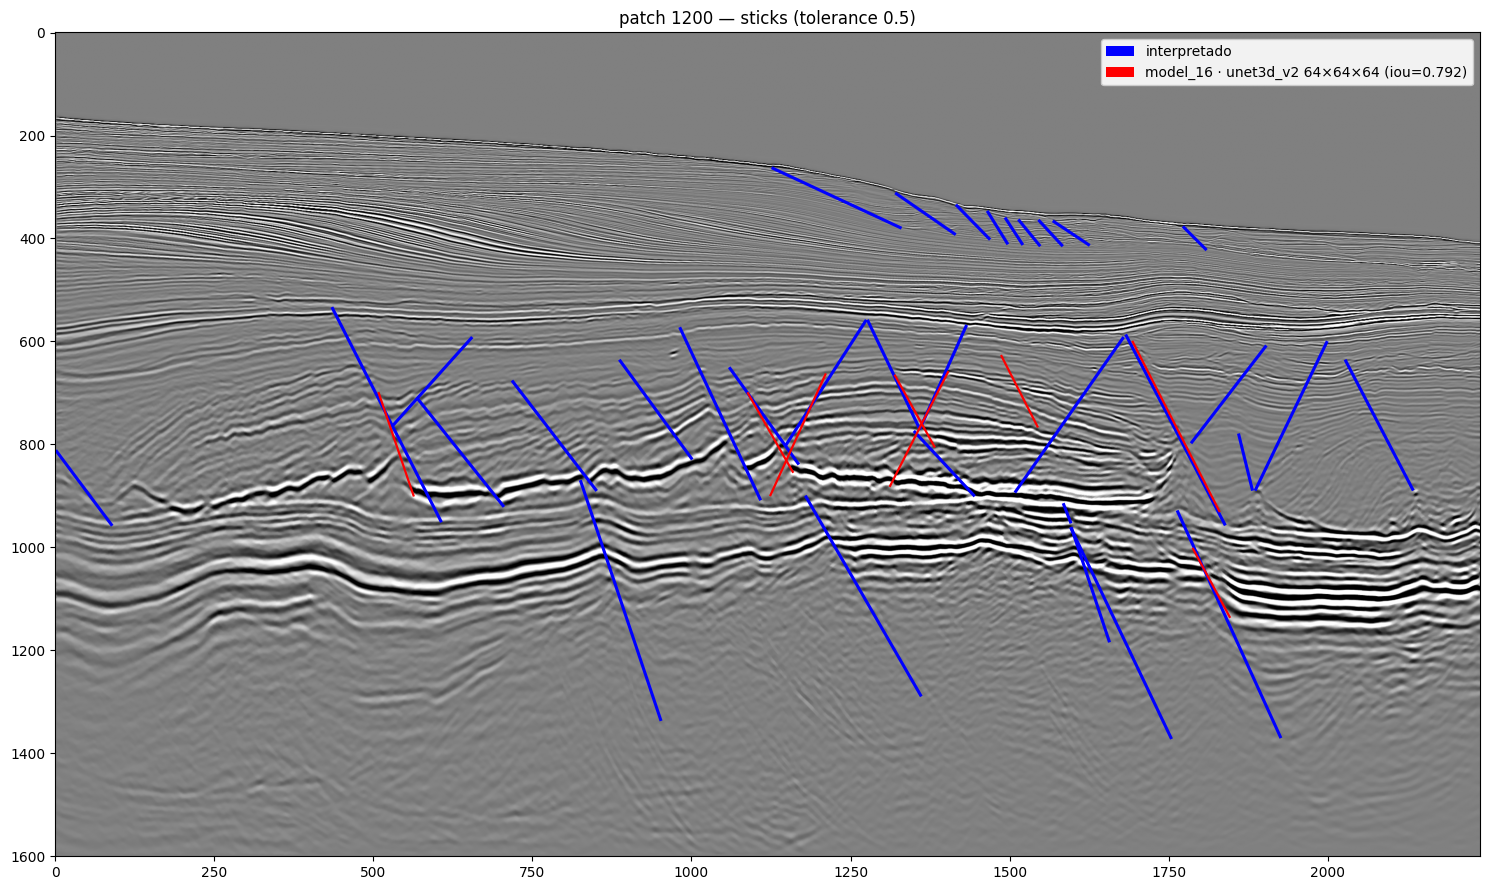

,modelo,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt
0,model_16 · unet3d_v2 64×64×64 (iou=0.792),0.17,0.152,0.713,0.275,8,33,187.0,1662,7454


In [6]:
PATCH = 1200
MODEL = models[0]

model    = modelSummary(MODEL)
comparer = FaultComparer(img=f'{MARLIM_DIR}/patch_{PATCH}', preds=[
    {'label': 'interpretado', 'path': f'files/patches/{PATCH}/{PATCH}_interpretado.png', 'color': 'blue'},
    {'label': model['rotulo'], 'path': f'{BASE_PATH}/{MODEL}/marlim/patch_{PATCH}',      'color': 'red'},
])

for mode in ('both', 'seismic', 'sticks'):
    comparer.show(mode=mode, title=f'patch {PATCH}')

comparer.report()

In [7]:
pd.DataFrame([comparer.metrics(model['rotulo'], tolerance=t) | {'tolerance': t} for t in (0.2, STICK_TOL, 0.8)])

,modelo,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt,tolerance
0,model_16 · unet3d_v2 64×64×64 (iou=0.792),0.109,0.091,0.737,0.191,5,33,168.0,1029,7454,0.2
1,model_16 · unet3d_v2 64×64×64 (iou=0.792),0.170,0.152,0.713,0.275,8,33,187.0,1662,7454,0.5
2,model_16 · unet3d_v2 64×64×64 (iou=0.792),0.204,0.182,0.597,0.304,11,33,219.1,2380,7454,0.8


# RECONSTRUÇÃO DAS PREDIÇÕES
Varre todos os modelos de `BASE_PATH` que possuem a pasta `marlim/`, reconstrói o volume
predito de cada patch a partir dos tiles `.dat` em `masks/` e salva tudo dentro da própria
pasta do patch (`marlim/patch_{id}/`):

- `predicted.npy` — volume de probabilidade reconstruído
- `predicted_seismic.png` / `predicted_mask.png` — máscara sobre a sísmica e em fundo preto
- `predicted_sticks.png` — **nossos sticks vs os do especialista**

A montagem independe da janela de treino: o `Predict.ipynb` sempre grava um tile inteiro por
`.dat` de entrada, então modelo de 128³, 64³, 32³ ou 32×64×16 entra aqui do mesmo jeito.

No fim a tabela de convergência (agrupada por patch, do maior `recall` para o menor) registra
a janela do modelo e a sobreposição usada na predição, e é salva em
`files/comparisons/sticks_report_<base>.csv` — um arquivo por `BASE_PATH`, porque os nomes
de modelo se repetem entre as pastas e misturá-los confunde.

In [8]:
REBUILD = False    # True remonta o volume mesmo quando o predicted.npy já existe


# MONTA O VOLUME PREDITO DE UM PATCH, SALVA AS TRÊS FIGURAS E DEVOLVE A LINHA DA TABELA
def comparePatch(model, patchDir, rebuild=REBUILD):
    patchName = os.path.basename(patchDir)
    patchId   = patchName.replace('patch_', '')
    annPath   = f'files/patches/{patchId}/{patchId}_interpretado.png'

    preds  = [{'label': 'interpretado', 'path': annPath, 'color': 'blue'}] if os.path.exists(annPath) else []
    preds += [{'label': model['rotulo'], 'path': patchDir, 'color': 'red'}]

    comparer = FaultComparer(img=f'{MARLIM_DIR}/{patchName}', preds=preds, tolerance=STICK_TOL,
                             metadata=f'{MARLIM_DIR}/{patchName}/patch_metadata.json')
    npyPath = os.path.join(patchDir, 'predicted.npy')

    if os.path.exists(npyPath) and not rebuild:
        vol = np.load(npyPath, mmap_mode='r')
    else:
        try:
            vol = comparer.reconstruct(comparer.tiles(patchDir), desc=f'{model["nome"]}/{patchName}')
        except FileNotFoundError:
            return None
        np.save(npyPath, vol)

    comparer.setSection(model['rotulo'], vol[comparer.inline])
    del vol

    title = f'{patchName} (fatia {comparer.inline}) — {model["rotulo"]}'
    comparer.show(mode='seismic', title=title, save=os.path.join(patchDir, 'predicted_seismic.png'))
    comparer.show(mode='mask',    title=title, save=os.path.join(patchDir, 'predicted_mask.png'))

    if comparer.reference() is None:
        return None

    metrics = comparer.metrics(model['rotulo'])
    comparer.show(mode='sticks', save=os.path.join(patchDir, 'predicted_sticks.png'),
                  title=f'{title} — recall={metrics["recall"]} deteccao={metrics["deteccao"]} precisao={metrics["precisao"]}')

    run = predictSummary(patchDir)
    return {'modelo': model['nome'], 'rede': model['rede'], 'janela': model['janela'],
            'iou_teste': model['iou_teste'], 'overlap': run.get('overlap'),
            'patch': patchId, 'fatia': comparer.inline,
            **{k: v for k, v in metrics.items() if k != 'modelo'}}


rows = []
for name in models:
    model  = modelSummary(name)
    marlim = os.path.join(BASE_PATH, name, 'marlim')

    for patchName in sorted(os.listdir(marlim)):
        row = comparePatch(model, os.path.join(marlim, patchName))
        if row:
            rows.append(row)

pd.DataFrame(rows)

figura salva em ../Model/Backup/model_16/marlim/patch_1200/predicted_seismic.png
figura salva em ../Model/Backup/model_16/marlim/patch_1200/predicted_mask.png
figura salva em ../Model/Backup/model_16/marlim/patch_1200/predicted_sticks.png
figura salva em ../Model/Backup/model_16/marlim/patch_1300/predicted_seismic.png
figura salva em ../Model/Backup/model_16/marlim/patch_1300/predicted_mask.png
figura salva em ../Model/Backup/model_16/marlim/patch_1300/predicted_sticks.png
figura salva em ../Model/Backup/model_16/marlim/patch_1400/predicted_seismic.png
figura salva em ../Model/Backup/model_16/marlim/patch_1400/predicted_mask.png
figura salva em ../Model/Backup/model_16/marlim/patch_1400/predicted_sticks.png
figura salva em ../Model/Backup/model_16/marlim/patch_2600/predicted_seismic.png
figura salva em ../Model/Backup/model_16/marlim/patch_2600/predicted_mask.png
figura salva em ../Model/Backup/model_16/marlim/patch_2600/predicted_sticks.png
figura salva em ../Model/Backup/model_17/mar

model_19/patch_1200: 100%|██████████| 910/910 [00:01<00:00, 694.21it/s]


figura salva em ../Model/Backup/model_19/marlim/patch_1200/predicted_seismic.png
figura salva em ../Model/Backup/model_19/marlim/patch_1200/predicted_mask.png
figura salva em ../Model/Backup/model_19/marlim/patch_1200/predicted_sticks.png
figura salva em ../Model/Backup/model_8/marlim/patch_1200/predicted_seismic.png
figura salva em ../Model/Backup/model_8/marlim/patch_1200/predicted_mask.png
figura salva em ../Model/Backup/model_8/marlim/patch_1200/predicted_sticks.png


,modelo,rede,janela,iou_teste,overlap,patch,fatia,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt
0,model_16,unet3d_v2,64×64×64,0.7916,0.25,1200,16,0.170,0.152,0.713,0.275,8,33,187.0,1662,7454
1,model_16,unet3d_v2,64×64×64,0.7916,0.25,1300,52,0.134,0.083,0.419,0.203,9,24,161.0,1600,5345
2,model_16,unet3d_v2,64×64×64,0.7916,0.25,1400,24,0.186,0.222,0.454,0.264,11,18,186.0,2081,5605
3,model_16,unet3d_v2,64×64×64,0.7916,0.25,2600,8,0.097,0.000,0.684,0.170,10,30,158.6,1687,13087
4,model_17,unet3d_v2,32×32×32,0.7863,0.25,1200,16,0.087,0.061,0.428,0.145,7,33,185.0,1430,7454
5,model_17,unet3d_v2,32×32×32,0.7863,0.25,1300,52,0.120,0.083,0.599,0.200,6,24,162.5,1002,5345
6,model_17,unet3d_v2,32×32×32,0.7863,0.25,1400,24,0.074,0.111,0.457,0.127,4,18,195.0,756,5605
7,model_17,unet3d_v2,32×32×32,0.7863,0.25,2600,8,0.048,0.033,0.696,0.091,5,30,160.0,843,13087
8,model_19,resaceunet_grva,128×128×128,0.7791,0.25,1200,16,0.396,0.273,0.182,0.250,64,33,198.5,17177,7454
9,model_8,unet3d_v2,128×128×128,0.7631,NaN,1200,16,0.000,0.000,0.000,0.000,0,33,0.0,0,7454


In [ ]:
REPORT_PATH = os.path.join(FIGURES_DIR, f'sticks_report_{os.path.basename(BASE_PATH.rstrip("/")).lower()}.csv')
report      = pd.DataFrame(rows)

if len(report):
    # a marlim/ de cada modelo é apagada de tempos em tempos (uns 7 GB por patch) e o CSV
    # acaba sendo o único registro — então só as linhas remontadas agora são trocadas
    if os.path.exists(REPORT_PATH):
        previous = pd.read_csv(REPORT_PATH, dtype={'patch': str})
        current  = set(zip(report.modelo, report.patch))
        previous = previous[[key not in current for key in zip(previous.modelo, previous.patch)]]

        for column in ('rede', 'janela', 'iou_teste'):
            previous[column] = [modelSummary(name)[column] for name in previous.modelo]

        report = pd.concat([report, previous], ignore_index=True)

    report = report.sort_values(['patch', 'recall'], ascending=[True, False]).reset_index(drop=True)

    os.makedirs(FIGURES_DIR, exist_ok=True)
    report.to_csv(REPORT_PATH, index=False)
    print(f'tabela salva em {REPORT_PATH}')

report

tabela salva em files/comparisons/sticks_report_backup.csv


,modelo,rede,janela,iou_teste,overlap,patch,fatia,recall,deteccao,precisao,f1,sticks,falhas_gt,len_p50,len_total,len_total_gt
0,model_19,resaceunet_grva,128×128×128,0.7791,0.25,1200,16,0.396,0.273,0.182,0.250,64,33,198.5,17177,7454
1,model_16,unet3d_v2,64×64×64,0.7916,0.25,1200,16,0.170,0.152,0.713,0.275,8,33,187.0,1662,7454
2,model_17,unet3d_v2,32×32×32,0.7863,0.25,1200,16,0.087,0.061,0.428,0.145,7,33,185.0,1430,7454
3,model_8,unet3d_v2,128×128×128,0.7631,NaN,1200,16,0.000,0.000,0.000,0.000,0,33,0.0,0,7454
4,model_16,unet3d_v2,64×64×64,0.7916,0.25,1300,52,0.134,0.083,0.419,0.203,9,24,161.0,1600,5345
5,model_17,unet3d_v2,32×32×32,0.7863,0.25,1300,52,0.120,0.083,0.599,0.200,6,24,162.5,1002,5345
6,model_16,unet3d_v2,64×64×64,0.7916,0.25,1400,24,0.186,0.222,0.454,0.264,11,18,186.0,2081,5605
7,model_17,unet3d_v2,32×32×32,0.7863,0.25,1400,24,0.074,0.111,0.457,0.127,4,18,195.0,756,5605
8,model_16,unet3d_v2,64×64×64,0.7916,0.25,2600,8,0.097,0.000,0.684,0.170,10,30,158.6,1687,13087
9,model_17,unet3d_v2,32×32×32,0.7863,0.25,2600,8,0.048,0.033,0.696,0.091,5,30,160.0,843,13087
